# Notebook 6 — Risk Prediction & Insights

Score every employee with an attrition probability, bucket them into risk tiers, and surface actionable HR insights.

## Setup & Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

from xgboost import XGBClassifier

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

RANDOM_STATE = 42
pd.set_option('display.max_columns', 50)

## Load Artifacts

In [11]:
import joblib

df             = pd.read_csv('df_raw_clean.csv')
X_test_scaled  = pd.read_csv('X_test_scaled.csv')
X_test         = pd.read_csv('X_test.csv')
y_test         = pd.read_csv('y_test.csv').squeeze()
scaler         = joblib.load('feature_scaler.pkl')
feature_columns= joblib.load('feature_columns.pkl')
numerical_cols = joblib.load('numerical_columns.pkl')
best_model     = joblib.load('best_attrition_model.pkl')

RANDOM_STATE = 42
best_model_name = type(best_model).__name__

## 8. Risk Prediction Module

Score every employee in the test set and bucket into **Low / Medium / High** risk tiers.

In [3]:
def predict_attrition_risk(model, X_data, raw_df_subset, threshold_low=0.30, threshold_high=0.60):
    """
    Returns a DataFrame with attrition risk probabilities and a risk tier
    for each row in X_data (must be preprocessed/scaled the same way as training data).
    raw_df_subset should be the original (unencoded) rows, aligned by index, for readability.
    """
    proba = model.predict_proba(X_data)[:, 1]

    risk_df = raw_df_subset.copy()
    risk_df['Attrition_Risk_%'] = (proba * 100).round(1)

    def tier(p):
        if p < threshold_low:
            return 'Low'
        elif p < threshold_high:
            return 'Medium'
        else:
            return 'High'

    risk_df['Risk_Tier'] = proba
    risk_df['Risk_Tier'] = risk_df['Risk_Tier'].apply(tier)

    return risk_df.sort_values('Attrition_Risk_%', ascending=False)


# Apply to the test set, using the best model found above
test_raw = df.loc[X_test.index]  # original readable columns for the same test rows
risk_report = predict_attrition_risk(best_model, X_test_scaled, test_raw)

cols_to_show = ['Age', 'Department', 'JobRole', 'MonthlyIncome', 'OverTime',
                'YearsAtCompany', 'Attrition', 'Attrition_Risk_%', 'Risk_Tier']
risk_report[cols_to_show].head(15)


,Age,Department,JobRole,MonthlyIncome,OverTime,YearsAtCompany,Attrition,Attrition_Risk_%,Risk_Tier
214,30,Research & Development,Research Scientist,2657,Yes,5,Yes,99.1,High
92,30,Sales,Sales Executive,5209,Yes,11,No,98.6,High
200,27,Research & Development,Manufacturing Director,4298,No,2,No,96.5,High
95,54,Research & Development,Research Director,13549,No,4,No,95.8,High
256,42,Research & Development,Laboratory Technician,2593,Yes,9,No,95.6,High
81,35,Research & Development,Research Scientist,2859,No,6,No,95.0,High
57,35,Research & Development,Laboratory Technician,4014,Yes,2,No,94.0,High
35,43,Research & Development,Research Scientist,2645,No,5,No,92.7,High
158,40,Sales,Sales Executive,10855,No,12,No,92.0,High
287,38,Research & Development,Healthcare Representative,5745,No,2,No,90.5,High


Risk_Tier
Low       160
Medium     75
High       59
Name: count, dtype: int64


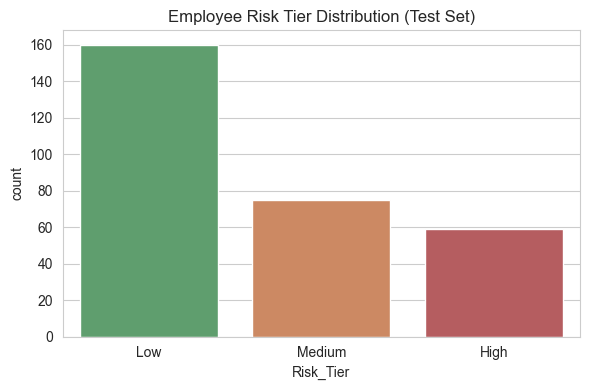

In [4]:
# Risk tier distribution
print(risk_report['Risk_Tier'].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(data=risk_report, x='Risk_Tier', order=['Low', 'Medium', 'High'],
              palette={'Low': '#55A868', 'Medium': '#DD8452', 'High': '#C44E52'})
plt.title('Employee Risk Tier Distribution (Test Set)')
plt.tight_layout()
plt.show()


In [6]:
def predict_single_employee(model, scaler, employee_dict, feature_columns, numerical_cols):
    """
    Predict attrition risk for ONE new employee.
    employee_dict: dict of raw feature values, e.g. {'Age': 34, 'Department': 'Sales', ...}
    Must include all original columns except the ones we dropped (EmployeeCount, StandardHours,
    Over18, EmployeeNumber) and except 'Attrition' itself.
    """
    single_df = pd.DataFrame([employee_dict])
    single_encoded = pd.get_dummies(single_df)

    # Align columns with training data (fill missing one-hot columns with 0)
    single_encoded = single_encoded.reindex(columns=feature_columns, fill_value=0)

    single_encoded[numerical_cols] = scaler.transform(single_encoded[numerical_cols])

    proba = model.predict_proba(single_encoded)[0, 1]
    return round(proba * 100, 1)


# Example: a single new employee
example_employee = {
    'Age': 29, 'BusinessTravel': 'Travel_Frequently', 'DailyRate': 800,
    'Department': 'Sales', 'DistanceFromHome': 15, 'Education': 3,
    'EducationField': 'Marketing', 'EnvironmentSatisfaction': 2, 'Gender': 'Male',
    'HourlyRate': 60, 'JobInvolvement': 2, 'JobLevel': 1, 'JobRole': 'Sales Representative',
    'JobSatisfaction': 2, 'MaritalStatus': 'Single', 'MonthlyIncome': 2800,
    'MonthlyRate': 15000, 'NumCompaniesWorked': 3, 'OverTime': 'Yes',
    'PercentSalaryHike': 12, 'PerformanceRating': 3, 'RelationshipSatisfaction': 2,
    'StockOptionLevel': 0, 'TotalWorkingYears': 5, 'TrainingTimesLastYear': 2,
    'WorkLifeBalance': 2, 'YearsAtCompany': 2, 'YearsInCurrentRole': 1,
    'YearsSinceLastPromotion': 0, 'YearsWithCurrManager': 1
}

risk_pct = predict_single_employee(best_model, scaler, example_employee, feature_columns, numerical_cols)
print(f"Predicted attrition risk for this employee: {risk_pct}%")


Predicted attrition risk for this employee: 99.6%


## 9. Analytics & Insights Summary

In [7]:
# Department-wise attrition rate (actual, from raw data)
dept_summary = df.groupby('Department')['Attrition'].apply(lambda x: (x == 'Yes').mean() * 100).round(1)
print("Attrition rate by Department (%):")
print(dept_summary.sort_values(ascending=False))
print()

# OverTime impact
ot_summary = df.groupby('OverTime')['Attrition'].apply(lambda x: (x == 'Yes').mean() * 100).round(1)
print("Attrition rate by OverTime (%):")
print(ot_summary)
print()

# Job satisfaction impact
js_summary = df.groupby('JobSatisfaction')['Attrition'].apply(lambda x: (x == 'Yes').mean() * 100).round(1)
print("Attrition rate by Job Satisfaction level (%):")
print(js_summary)


Attrition rate by Department (%):
Department
Sales                     20.6
Human Resources           19.0
Research & Development    13.8
Name: Attrition, dtype: float64

Attrition rate by OverTime (%):
OverTime
No     10.4
Yes    30.5
Name: Attrition, dtype: float64

Attrition rate by Job Satisfaction level (%):
JobSatisfaction
1    22.8
2    16.4
3    16.5
4    11.3
Name: Attrition, dtype: float64


In [15]:
# 1. Safely define the best model's name dynamically
best_model_name = type(best_model).__name__

# 2. Extract importances using coefficients for Logistic Regression
if hasattr(best_model, "feature_importances_"):
    importances = best_model.feature_importances_
elif hasattr(best_model, "coef_"):
    # Take the absolute value of coefficients to see overall impact strength
    importances = np.abs(best_model.coef_[0])
else:
    importances = np.zeros(len(feature_columns))

# Create the importance DataFrame
xgb_importance = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

# 3. Print the formatted block
print("=" * 60)
print("KEY TAKEAWAYS")
print("=" * 60)
print(f"\n1. Best performing model: {best_model_name}")

print(f"\n2. Top 5 drivers of attrition ({best_model_name} importance):")
print(xgb_importance.head(5).to_string())

print(f"\n3. High-risk employees in test set: {(risk_report['Risk_Tier'] == 'High').sum()} "
      f"out of {len(risk_report)} ({(risk_report['Risk_Tier'] == 'High').mean()*100:.1f}%)")

KEY TAKEAWAYS

1. Best performing model: LogisticRegression

2. Top 5 drivers of attrition (LogisticRegression importance):
                            Feature  Importance
0                      OverTime_Yes    1.623568
1  BusinessTravel_Travel_Frequently    1.598904
2     JobRole_Laboratory Technician    1.569722
3      JobRole_Sales Representative    1.276684
4         JobRole_Research Director    1.117217

3. High-risk employees in test set: 59 out of 294 (20.1%)


## 10. Save Final Artifacts

In [17]:
import joblib

joblib.dump(best_model, 'best_attrition_model.pkl')
joblib.dump(scaler, 'feature_scaler.pkl')
# Fix: Use the feature_columns variable that you already have loaded
joblib.dump(feature_columns, 'feature_columns.pkl') 
joblib.dump(numerical_cols, 'numerical_columns.pkl')

print("Saved: best_attrition_model.pkl, feature_scaler.pkl, feature_columns.pkl, numerical_columns.pkl")

Saved: best_attrition_model.pkl, feature_scaler.pkl, feature_columns.pkl, numerical_columns.pkl
